In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline

In [6]:
###从sql中读取数据
conn = sqlite3.connect('molecular_descriptorsAML9.6.db')
query = "SELECT * FROM data"
df1 = pd.read_sql(query, conn)
df2 = df1.drop(columns = "SMILES")

In [7]:
# 1. 逐元素检查是否为空字符串，返回布尔值矩阵
mask = df2.apply(lambda col: col.map(lambda x: x == ''))

# 2. 按行检查是否存在True（空字符串）
rows_with_empty = mask.any(axis=1)

# 3. 删除包含空字符串的行
df3 = df2[~rows_with_empty]

# 重置索引（删除原索引，生成新的连续整数索引）
df3 = df3.reset_index(drop=True)

mapping = {"active": 1, "Inactive": 0}
df3["Activity2"] = df3["Activity"].map(mapping).fillna(0)
df3= df3.drop(columns = "Activity")

#验证，转换全量数据为浮点类型
df3 = df3.astype(float)
conn.close()

# 假设最后一列是目标变量
X = df3.iloc[:, :-1]
y = df3.iloc[:, -1]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 如果特征是连续值，可进行标准化（高斯朴素贝叶斯对连续值更友好）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



开始 RFECV 特征筛选...
Fitting estimator with 119 features.
Fitting estimator with 118 features.
Fitting estimator with 117 features.
Fitting estimator with 116 features.
Fitting estimator with 115 features.
Fitting estimator with 114 features.
Fitting estimator with 113 features.
Fitting estimator with 112 features.
Fitting estimator with 111 features.
Fitting estimator with 110 features.
Fitting estimator with 109 features.
Fitting estimator with 108 features.
Fitting estimator with 107 features.
Fitting estimator with 106 features.
Fitting estimator with 105 features.
Fitting estimator with 104 features.
Fitting estimator with 103 features.
Fitting estimator with 102 features.
Fitting estimator with 101 features.
Fitting estimator with 100 features.
Fitting estimator with 99 features.
Fitting estimator with 98 features.
Fitting estimator with 97 features.
Fitting estimator with 96 features.
Fitting estimator with 95 features.
Fitting estimator with 94 features.
Fitting estimator with 93 

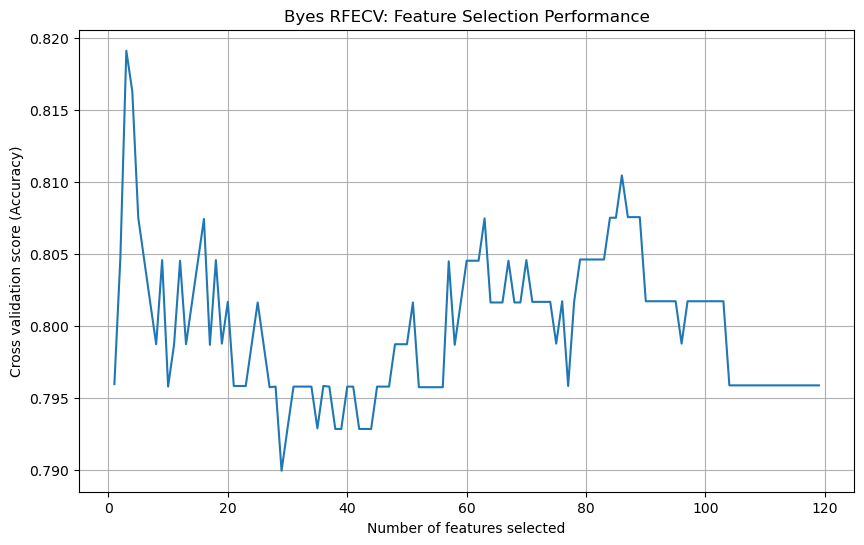

特征筛选后，训练集特征数: 3
特征筛选后，测试集特征数: 3


In [11]:
# 3. 步骤一: 使用 RFECV 进行特征筛选
print("\n" + "="*50)
print("开始 RFECV 特征筛选...")
print("="*50)

def get_gpc_importance(pipeline):
    """
    从包含 GaussianProcessClassifier 的 Pipeline 中提取特征重要性。
    确保返回与特征数量相同的数组。
    """
    # 获取 Pipeline 中的最后一步模型，即 GPC
    gpc_model = pipeline.named_steps['gpc']
    
    # 获取拟合后的核函数
    fitted_kernel = gpc_model.kernel_
    
    # 检查核函数是否是我们预期的形式 (ConstantKernel * RBF)
    if isinstance(fitted_kernel, RBF):
        rbf_kernel = fitted_kernel
    elif hasattr(fitted_kernel, 'k2') and isinstance(fitted_kernel.k2, RBF):
        rbf_kernel = fitted_kernel.k2
    else:
        raise ValueError("Kernel type not supported for importance extraction.")

    # 获取长度尺度参数
    length_scale = rbf_kernel.length_scale
    
    # 修复：从 pipeline 的 scaler 中获取特征数量（无需依赖外部 X）
    n_features = pipeline.named_steps['scaler'].n_features_in_
    if np.isscalar(length_scale):
        length_scales = np.full(n_features, length_scale)
    else:
        length_scales = np.asarray(length_scale)
    
    # 长度尺度越长，特征重要性越低，因此取倒数
    importances = 1.0 / length_scales
    
    return importances
    
# 2. 定义 Pipeline（确保导入所需库：RBF、ConstantKernel、StandardScaler等）
kernel_rfe = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gpc', GaussianProcessClassifier(kernel=kernel_rfe, random_state=42, n_restarts_optimizer=1))
])


# 3. 配置 RFECV（修复：直接传入 get_gpc_importance 函数）
rfecv = RFECV(
    estimator=pipeline,
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    importance_getter=get_gpc_importance  # 直接用函数名，无需 lambda
)


# 直接传入原始训练数据（管道内自动标准化）
# 假设 X_train_scaled 是训练集特征（若未标准化，可直接传 X_train，管道内会处理）
rfecv.fit(X_train_scaled, y_train)

# 输出 RFECV 结果
print(f"\nRFECV 找到的最佳特征数量: {rfecv.n_features_}")

# 绘制 RFECV 性能曲线
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (Accuracy)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.grid(True)
plt.title('Byes RFECV: Feature Selection Performance')
plt.show()

# 应用特征筛选（修复：测试集用 X_test_scaled）
X_train_selected = rfecv.transform(X_train_scaled)
X_test_selected = rfecv.transform(X_test_scaled)  # 改为测试集标准化数据

print(f"特征筛选后，训练集特征数: {X_train_selected.shape[1]}")
print(f"特征筛选后，测试集特征数: {X_test_selected.shape[1]}")

In [12]:
# 定义一个带有优化边界的核函数
# GPC在训练时会自动优化这些参数
kernel_for_gpc = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
model_for_grid = GaussianProcessClassifier(kernel=kernel_for_gpc, random_state=42)

# 只搜索那些不会被GPC自动优化的参数
param_grid = {
    'max_iter_predict': [100, 200, 300],
    # 你还可以搜索其他参数，比如 n_restarts_optimizer
    'n_restarts_optimizer': [0, 1, 2] 
}

# 执行网格搜索
grid_search = GridSearchCV(
    estimator=model_for_grid,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid_search.fit(X_train_selected, y_train)

print(f"\n最佳超参数组合: {grid_search.best_params_}")
print(f"交叉验证得到的最佳分数 (Accuracy): {grid_search.best_score_:.4f}")

# 最佳模型会自动 refit 在整个训练集上
best_gpc_model = grid_search.best_estimator_
print(f"\n自动优化后的核函数参数: {best_gpc_model.kernel_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits

最佳超参数组合: {'max_iter_predict': 100, 'n_restarts_optimizer': 0}
交叉验证得到的最佳分数 (Accuracy): 0.8046

自动优化后的核函数参数: 1.59**2 * RBF(length_scale=2.15)


In [13]:
# 5. 步骤三: 评估最终模型
print("\n" + "="*50)
print("评估最终模型性能 (在测试集上)...")
print("="*50)

# 获取最佳模型
best_final_model = grid_search.best_estimator_

# 在测试集上进行预测
# GPC的 predict_proba 方法返回每个类别的概率
y_pred_proba = best_final_model.predict_proba(X_test_selected)[:, 1] # 我们关注正类(1)的概率

# 为了计算分类指标，我们需要将概率转换为类别标签
# 默认阈值是 0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

# 计算各种评估指标
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba) # ROC-AUC 需要概率值

print(f"准确率 (Accuracy): {accuracy:.4f}")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall): {recall:.4f}")
print(f"F1 分数 (F1-Score): {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


# 打印混淆矩阵（可选）
print("\n混淆矩阵 (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))


评估最终模型性能 (在测试集上)...
准确率 (Accuracy): 0.8299
精确率 (Precision): 0.7500
召回率 (Recall): 0.4865
F1 分数 (F1-Score): 0.5902
ROC-AUC: 0.6990

混淆矩阵 (Confusion Matrix):
[[104   6]
 [ 19  18]]


In [22]:
# 详细分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred,digits=4))


分类报告:
              precision    recall  f1-score   support

         0.0     0.8455    0.9455    0.8927       110
         1.0     0.7500    0.4865    0.5902        37

    accuracy                         0.8299       147
   macro avg     0.7978    0.7160    0.7414       147
weighted avg     0.8215    0.8299    0.8166       147



In [17]:
print("y_pred_proba 形状:", y_pred_proba.shape)
print("y_pred_proba 前5个元素:", y_pred_proba[:5])
print("y_pred 形状:", y_pred.shape)
print("y_pred 前5个元素:", y_pred[:5])

y_pred_proba 形状: (147,)
y_pred_proba 前5个元素: [0.18697773 0.11811335 0.77709613 0.27968324 0.22824764]
y_pred 形状: (147,)
y_pred 前5个元素: [0 0 1 0 0]


In [19]:
###保存预测概率
# 对于二分类问题，我们通常需要正类的概率
y_pred_proba_model2 = y_pred

# 保存结果
# 建议将真实标签也一起保存，虽然它们应该是相同的，但这样更保险
results_model2 = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba_model2': y_pred_proba_model2
})

# 将结果保存到一个CSV文件
results_model2.to_csv('D:\\AAA科研——高老师\\AML-论文撰写资料\\model2_results.csv', index=False)
print("beiyesi results exported successfully.")

beiyesi results exported successfully.
